<img src="images/m-rainbow.svg" width="5%" height="5%">

<h1 style="font-size: 30px; font-weight: bold; color: #ff2f05;">
  The Mistral AI Python SDK
</h1>

The Mistral AI Python SDK (**S**oftware **D**evelopment **K**it) is a wrapper for the **Mistral AI API**.

You can find the official documentation and some examples in:
- The [Vibe Studio Product Section](https://docs.mistral.ai/studio-api/overview) 
- The [API reference](https://docs.mistral.ai/api)
- The [Developers Section](https://docs.mistral.ai/developers)
- Their Github [Python SDK](https://github.com/mistralai/client-python) and [Cookbook](https://github.com/mistralai/cookbook) repositories
- Their [YouTube Streams](https://www.youtube.com/@MistralAIOfficial/streams)

<h2 style="font-size: 25px; font-weight: bold; color: #fb6227;">
  10. Document AI
</h2>

**Document AI** is an umbrella for 2 main functionalities (same endpoint, additional parameters):
- The basic [**OCR Processor**](https://docs.mistral.ai/studio-api/document-processing/basic_ocr) to extract text from documents
- The optional [**Document Annotations**](https://docs.mistral.ai/studio-api/document-processing/annotations) for structured outputs and image descriptions (produced by `mistral-small` based on the OCR output)

The documentation also mentions [**Document Q&A**](https://docs.mistral.ai/studio-api/document-processing/document_qna) but this is simply the ability to use the Chat Completion endpoint with a vision-capable model as we did in the second notebook.

<h3 style="font-size: 20px; font-weight: bold; color: #ff8f1e;">
  10.1 Environment Preparation
</h3>

Let's upgrade the SDK, define a few convenience functions and instantiate the main client.

In [ ]:
%pip install --upgrade mistralai
%pip install pillow requests pandas

In [ ]:
from mistralai.client import Mistral
from mistralai.client.models import ImageURLChunk, DocumentURLChunk, OCRResponse, OCRSignatureBlock, SystemMessage, UserMessage
from mistralai.client.types import UNSET
from typing import Literal
import base64
from dotenv import load_dotenv
from io import BytesIO
from IPython.display import Markdown, Image, display
import os
from PIL import Image as PILImage, ImageDraw
import requests

In [ ]:
# Started from the Mistral AI Cookbook (https://github.com/mistralai/cookbook/blob/main/mistral/ocr/data_extraction.ipynb)
# and added the replace_tables_in_markdown function (if table_format is "markdown" or "html")

def replace_images_in_markdown(markdown_str: str, images_dict: dict[str, str]) -> str:
    """Replace image placeholders in markdown with base64-encoded images."""
    for img_name, base64_str in images_dict.items():
        markdown_str = markdown_str.replace(f"![{img_name}]({img_name})", f"![{img_name}]({base64_str})")
    return markdown_str

def replace_tables_in_markdown(markdown_str: str, tables_dict: dict[str, str]) -> str:
    """Replace table placeholders like [tbl-0.md](tbl-0.md) with raw markdown table content."""
    for tbl_id, tbl_content in tables_dict.items():
        markdown_str = markdown_str.replace(f"[{tbl_id}]({tbl_id})", tbl_content)
    return markdown_str

def get_combined_markdown(ocr_response: OCRResponse) -> str:
    """Combine OCR text, tables, and images from all pages into a single markdown document."""
    markdowns: list[str] = []
    
    for page in ocr_response.pages:

        image_data = {img.id: img.image_base64 for img in page.images}
        table_data = {tbl.id: tbl.content for tbl in page.tables} if page.tables else {}
        
        processed_md = page.markdown
        processed_md = replace_images_in_markdown(processed_md, image_data)
        processed_md = replace_tables_in_markdown(processed_md, table_data)
        
        markdowns.append(processed_md)

    return "\n\n".join(markdowns)

In [ ]:
# Functions to draw boxes on the image --------------------------------------
BLOCK_COLORS = {
    "text": "blue",
    "title": "darkmagenta",
    "list": "green",
    "table": "purple",
    "image": "orange",
    "equation": "teal",
    "caption": "brown",
    "code": "darkcyan",
    "references": "darkred",
    "aside_text": "olive",
    "header": "gray",
    "footer": "dimgray",
    "signature": "red",
}

def _load_image(image_source: str) -> PILImage.Image:
    """
    Loads an image from either a web URL or a local base64 data URI string.
    """
    if image_source.startswith("data:image"):
        _, base64_data = image_source.split(",", 1)
        image_bytes = base64.b64decode(base64_data)
        return PILImage.open(BytesIO(image_bytes)).convert("RGB")
    
    response = requests.get(image_source)
    return PILImage.open(BytesIO(response.content)).convert("RGB")

def _draw_bounding_box(draw: ImageDraw.ImageDraw, block, color: str, width: int) -> None:
    """Draws a single bounding box on the ImageDraw object."""
    coords = [
        block.top_left_x, 
        block.top_left_y, 
        block.bottom_right_x, 
        block.bottom_right_y
    ]
    draw.rectangle(coords, outline=color, width=width)

def highlight_blocks(
    image_url: str, 
    ocr_response: OCRResponse, 
    types_to_include: list[str] = None, 
    outline_width: int = 2
) -> PILImage.Image:
    """
    Highlights OCR blocks on an image. Handles both web URLs and base64 strings.
    """
    img = _load_image(image_url)
    draw = ImageDraw.Draw(img)
    
    allowed_types = set(types_to_include) if types_to_include else set(BLOCK_COLORS.keys())
    
    for page in ocr_response.pages:
        if not page.blocks:
            continue
            
        for block in page.blocks:
            if block.type in allowed_types:
                box_color = BLOCK_COLORS.get(block.type, "black")
                _draw_bounding_box(draw, block, box_color, outline_width)
                
    return img

# Function to verify if the document is signed ------------------------------
def is_document_signed(ocr_response: OCRResponse) -> bool:
    """
    Checks if the document is signed.
    Raises ValueError if block data is missing (None), indicating an invalid API request.
    """
    if any(page.blocks is None for page in ocr_response.pages):
        raise ValueError("Incomplete API request: one or more pages are missing block data.")

    return any(
        block.type == "signature"
        for page in ocr_response.pages
        for block in page.blocks
    )

# Function to encode local files to Base64 before upload --------------------
def encode_file_to_base64(file_path: str) -> str:
    with open(file_path, "rb") as file:
        file_contents = file.read()
    return base64.b64encode(file_contents).decode("utf-8")

In [ ]:
load_dotenv()
mistral = Mistral(api_key=os.environ["MISTRAL_API_KEY"])

<h3 style="font-size: 20px; font-weight: bold; color: #ff8f1e;">
  10.2 Basic OCR Processor
</h3>

The OCR output is organized in pages and the schema is like the one below (disregarded sections about annotations for now):

```python
{
  "pages": [
    {
      # Zero-based page number
      "index": int, 

      # Main output. 
      # Images are represented by placeholders but can be found in "images" (if include_image_base64=True)
      # Tables content is included, except if table_format is set to "markdown" or "html" (in this case, a placeholder is added and the tables can be found in "tables")
      "markdown": str, 

      # Images information (e.g. ID, coordinates).
      # The image content (Base64) is included in there if you set include_image_base64=True.
      "images": list, 

      # Table information when table_format="html" or table_format="markdown"
      # Otherwise, the tables content is directly included in line within "markdown"
      "tables": list, 

      # Hyperlinks detected
      "hyperlinks": list, 

      # Header content when extract_header=True
      # Otherwise, this is included within "markdown"
      "header": str | null,

      # Footer content when extract_footer=True
      # Otherwise, this is included within "markdown"
      "footer": str | null,

      # Dimensions of the page (dpi, height, width)
      "dimensions": dict, 

      # Confidence scores when confidence_scores_granularity is set to "word" or "page"
      "confidence_scores": dict | null, 

      # When include_blocks=True, each page contains a blocks array listing every block in reading order with its bounding box and content
      # Type can be: text, title, list, table, image, equation, caption, code, references, aside_text, header, footer, signature
      "blocks": list | null
    }
  ],

  # The model used for the OCR (e.g. "mistral-ocr-latest")
  "model": str,

  # Usage information (pages_processed, doc_size_bytes)
  "usage_info": dict 
}
```
---

And this is how you send a document to the OCR processor:

```python
mistral.ocr.process(

    # Use the latest OCR model to benefit from all capabilities
    model: str,

    # The document to pass to the OCR
    document: ImageURLChunk | DocumentURLChunk,

    # If True, it includes the images content in the response (not only placeholders)
    include_image_base64: bool | UNSET,

    # If this parameter is set to "markdown" or HTML, tables are stored in their own "tables" section and the "markdown" section will only include placeholders
    # If unset, tables will be included within the main content section named "markdown"
    # Tables are also included in "blocks" if include_blocks=True
    table_format: Literal["markdown", "html"] | UNSET,   

    # Can be set to "page" or "word" to calculate confidence scores at one of these levels
    # No scores will be calculated if the parameter is unset
    confidence_scores_granularity: Literal["page", "word"] | UNSET,

     # When True, each page contains a blocks array listing every block
    include_blocks: bool | UNSET,   

    # Headers are included in the "header" section if this parameter is set to true, instead of being included in "markdown"
    # If False or unset, headers will be included in "markdown" instead
    # Headers are also included in "blocks" if include_blocks=True
    extract_header: bool | UNSET,                
    
    # Footers are included in the "footer" section if this parameter is set to true, instead of being included in "markdown"
    # If False or unset, footers will be included in "markdown" instead
    # Footers are also included in "blocks" if include_blocks=True
    extract_footer: bool | UNSET
)
```

---

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.2.1 Bank Statement
</h4>

In some cases, bank statements are still received in PDF or image format (e.g. scanned paper version) and you may want to automate the data extraction.

In [ ]:
bank_statement_url = "https://s2.qwant.com/thumbr/474x613/c/3/a18cf44901b75d6c7a52a132086f3365986a56d1963c64dd44a8c6b675cf37/OIP.E4qbsLQf8FB7LZ4Z1bwTEgHaJl.jpg?u=https%3A%2F%2Ftse.mm.bing.net%2Fth%2Fid%2FOIP.E4qbsLQf8FB7LZ4Z1bwTEgHaJl%3Fpid%3DApi&q=0&b=1&p=0&a=0"
Image(url=bank_statement_url)

In [ ]:
# My main objective is to get the transactions table
ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=ImageURLChunk(image_url=bank_statement_url),         
    table_format="markdown",                   
    include_blocks=True              
)

print(ocr_response.model_dump_json(indent=2))

In [ ]:
Markdown(ocr_response.pages[0].tables[1].content)

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.2.2 Signature Verification
</h4>

Blocks can help you automate the signature presence verification on contracts.

In [ ]:
signature_img_url = "https://s1.qwant.com/thumbr/474x293/8/d/90ef215b4818fd0ab5cd0aa4ae47181e74377c1ee45dda514a0654dc1601d4/OIP.cQxw-W4TTP9r84LEDaX_dgHaEl.jpg?u=https%3A%2F%2Ftse.mm.bing.net%2Fth%2Fid%2FOIP.cQxw-W4TTP9r84LEDaX_dgHaEl%3Fpid%3DApi&q=0&b=1&p=0&a=0"
Image(url=signature_img_url)

In [ ]:
# My main objective is to check if a signature was found by inspecting "blocks"
ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=ImageURLChunk(image_url=signature_img_url),
    include_image_base64=True,
    include_blocks=True,
)

print(ocr_response.model_dump_json(indent=2))

In [ ]:
is_document_signed(ocr_response)

In [ ]:
marked_image = highlight_blocks(
    image_url=signature_img_url,
    ocr_response=ocr_response,
    types_to_include=["signature"]
)

display(marked_image)

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.2.3 Multiple Signatures
</h4>

In [ ]:
signature_img_url = "https://s2.qwant.com/thumbr/474x608/e/d/5c85b98b05bb87e3e4c92480dc4e060d6c2f7c570a84524875caa83e80af32/OIP._DyGoHGnVaqOWpv7uE39VwHaJg.jpg?u=https%3A%2F%2Ftse.mm.bing.net%2Fth%2Fid%2FOIP._DyGoHGnVaqOWpv7uE39VwHaJg%3Fpid%3DApi&q=0&b=1&p=0&a=0"
Image(url=signature_img_url)

In [ ]:
ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=ImageURLChunk(image_url=signature_img_url),
    include_image_base64=True,
    include_blocks=True,
)

In [ ]:
# Different approach here: we want to count the number of signature blocks
signatures = [block for block in ocr_response.pages[0].blocks if isinstance(block, OCRSignatureBlock)]
signatures_count = len(signatures)
signatures_count

In [ ]:
marked_image = highlight_blocks(
    image_url=signature_img_url,
    ocr_response=ocr_response,
    types_to_include=["signature"]
)

display(marked_image)

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.2.4 Supermarket Receipt
</h4>

In [ ]:
# Image taken from: https://www.kaggle.com/datasets/trainingdatapro/ocr-receipts-text-detection/data

# Local files must be encoded to Base64
base64_img = encode_file_to_base64("ocr/3.jpg")
img_url = f"data:image/png;base64,{base64_img}"
display(Image(url=img_url))

In [ ]:
ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=ImageURLChunk(image_url=img_url),
    include_image_base64=True,
    table_format="markdown",
    include_blocks=True,
)

print(ocr_response.model_dump_json(indent=2))

In [ ]:
Markdown(get_combined_markdown(ocr_response))

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.2.5 PDF Invoice
</h4>

https://github.com/femstac/Sample-Pdf-invoices

In [ ]:
# Local files must be encoded to Base64
pdf_base64 = encode_file_to_base64("ocr/invoice_Adrian Barton_35580.pdf")
document_url = f"data:application/pdf;base64,{pdf_base64}"

ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=DocumentURLChunk(document_url=document_url),
    include_image_base64=True,
    table_format="markdown",
    include_blocks=True
)

print(ocr_response.model_dump_json(indent=2))

In [ ]:
Markdown(get_combined_markdown(ocr_response))

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.2.6 PDF Article and Translation
</h4>

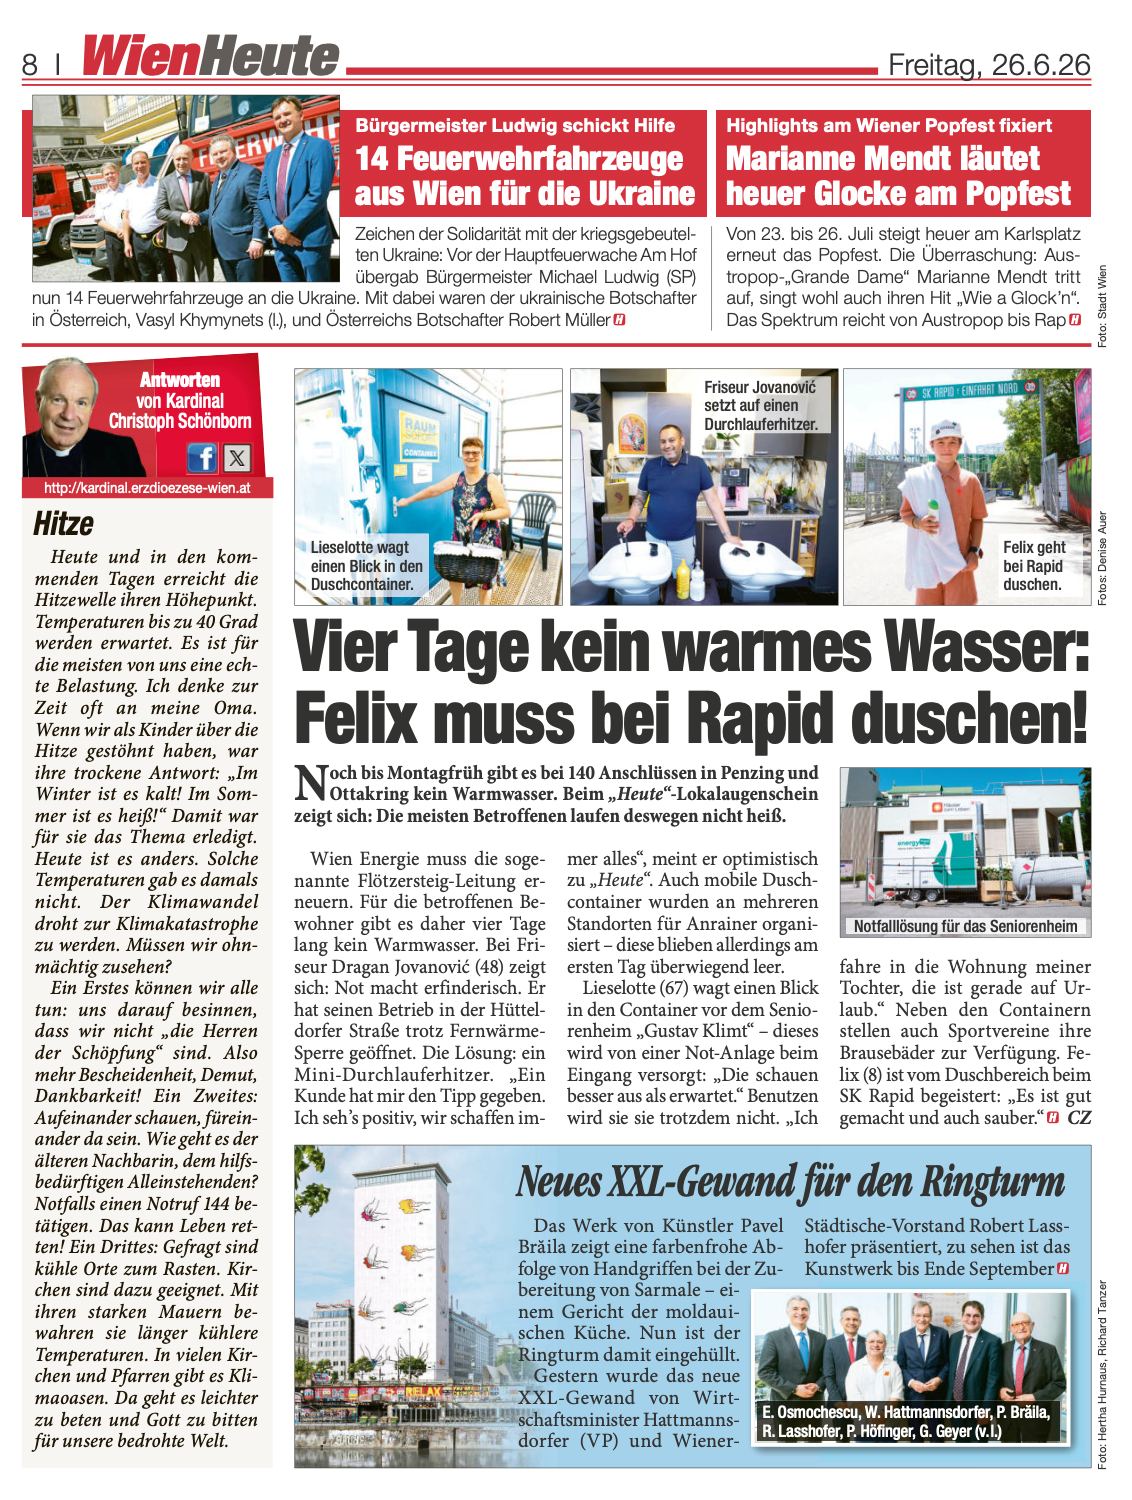

In [ ]:
# Local files must be encoded to Base64
pdf_base64 = encode_file_to_base64("ocr/heute.pdf")
document_url = f"data:application/pdf;base64,{pdf_base64}"

ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=DocumentURLChunk(document_url=document_url),
    include_image_base64=True,
    table_format="markdown",
    include_blocks=True,
    pages="7" # zero-based
)

Markdown(get_combined_markdown(ocr_response))

In [ ]:
# We can use a standard chat completion for further processing
chat_response = mistral.chat.complete(
    model="mistral-small-latest",
    messages=[
        SystemMessage(content="You are a professional German/English translator. You translate Austrian articles without compromising formatting."),
        UserMessage(content=f"Article: {ocr_response.pages[0].markdown}") # Don't pass the version with images!
    ]
)

# We swap the German text with the English one in the OCR response
# so we can still use the get_combined_markdown function to include images
translated_response = ocr_response
translated_response.pages[0].markdown = chat_response.choices[0].message.content
Markdown(get_combined_markdown(translated_response))

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.2.7 PDF Earnings Report
</h4>

Don't waste your time on manual data entries!

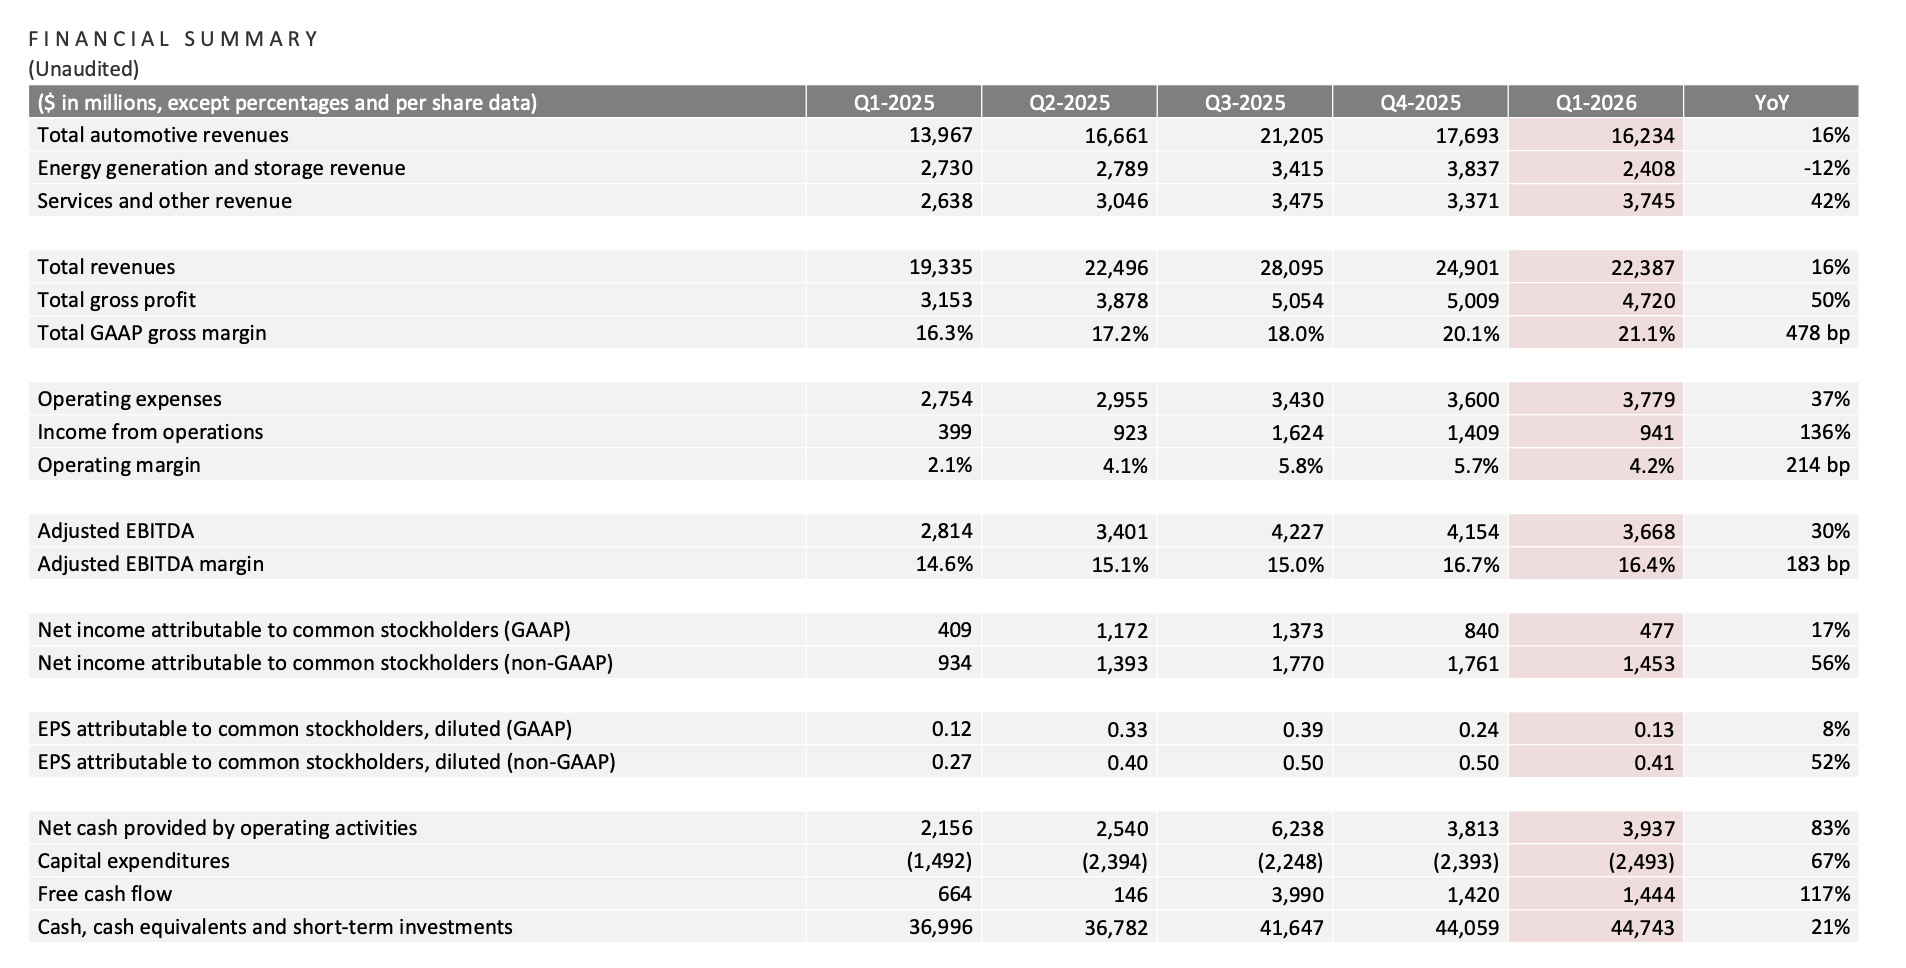

In [ ]:
# Local files must be encoded to Base64
pdf_base64 = encode_file_to_base64("ocr/TSLA-Q1-2026-Update.pdf")
document_url = f"data:application/pdf;base64,{pdf_base64}"

ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=DocumentURLChunk(document_url=document_url),
    include_image_base64=True,
    table_format="markdown",
    include_blocks=True,
    pages="3" # zero-based
)

Markdown(get_combined_markdown(ocr_response))

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.2.8 PowerPoint Presentation or Word Document
</h4>

In [ ]:
# https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fcdn.create.microsoft.com%2Fuploadedfiles%2Fuploads%2F334937b4-4466-4ea1-802b-b990ef59aa3a-TF740e6461-9b93-4a8d-8a06-e12b6b090328b5fa10a4_wac.pptx&wdOrigin=SEO-INTENT.SEARCHENGINE-LANDING-INTENT1000.USETEMPLATE

# Local files must be encoded to Base64
ppt_base64 = encode_file_to_base64("ocr/ppt_example.pptx")

# MIME for pptx: vnd.openxmlformats-officedocument.presentationml.presentation
# MIME for ppt: application/vnd.ms-powerpoint
# MIME for docx: application/vnd.openxmlformats-officedocument.wordprocessingml.document
# MIME for doc: application/msword
document_url = f"data:application/vnd.openxmlformats-officedocument.presentationml.presentation;base64,{ppt_base64}"

ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=DocumentURLChunk(document_url=document_url),
    include_image_base64=True,
    table_format="markdown",
    include_blocks=True,
)

Markdown(get_combined_markdown(ocr_response))

<h3 style="font-size: 20px; font-weight: bold; color: #ff8f1e;">
  10.3 Annotations
</h3>

[Annotations](https://docs.mistral.ai/studio-api/document-processing/annotations) provide structured OCR outputs for your documents and images.

Enforcing a structured format is essential for ensuring predictable data outputs that can be seamlessly processed by your downstream applications.

- `document_annotation`: Extracts structured data from the entire document based on a predefined annotation format and an optional user prompt.
- `bbox_annotation`: Extracts structured data for the images extracted by the OCR model based on a predefined annotation format (e.g. image description)

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.3.1 Document Annotation for the Bank Statement
</h4>

In [ ]:
bank_statement_url = "https://s2.qwant.com/thumbr/474x613/c/3/a18cf44901b75d6c7a52a132086f3365986a56d1963c64dd44a8c6b675cf37/OIP.E4qbsLQf8FB7LZ4Z1bwTEgHaJl.jpg?u=https%3A%2F%2Ftse.mm.bing.net%2Fth%2Fid%2FOIP.E4qbsLQf8FB7LZ4Z1bwTEgHaJl%3Fpid%3DApi&q=0&b=1&p=0&a=0"
Image(url=bank_statement_url)

In [ ]:
from pydantic import BaseModel, Field

class Transaction(BaseModel):
    date: str = Field(..., description="Transaction date in yyyy-mm-dd format")
    type: str
    description: str
    paid_in: float
    paid_out: float

class Statement(BaseModel):
    account_number: str
    previous_balance: float
    new_balance: float
    transactions: list[Transaction]

In [ ]:
from mistralai.extra import response_format_from_pydantic_model
import json

ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=ImageURLChunk(image_url=bank_statement_url),         
    document_annotation_format=response_format_from_pydantic_model(Statement),
    document_annotation_prompt="Extract the following from the bank statement: account number the statement relates to and transactions listed on the statement"              
)

annotations = json.loads(ocr_response.document_annotation)
annotations

In [ ]:
import pandas as pd

df = pd.DataFrame(annotations["transactions"])
df

In [ ]:
df["paid_out"].sum()

In [ ]:
df.groupby(["date"])[["paid_in", "paid_out"]].sum()

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.3.2 Document Annotation for the Earnings Report
</h4>

In [ ]:
pdf_base64 = encode_file_to_base64("ocr/TSLA-Q1-2026-Update.pdf")
document_url = f"data:application/pdf;base64,{pdf_base64}"

class LineItems(BaseModel):
    item: str = Field(..., description="The description of the financial KPI")
    lastest_quarter_figure: float = Field(..., description="The figure of the financial KPI for the latest quarter included in the report")

class Report(BaseModel):
    quarter: str = Field(..., description="The latest quarter included in the report in format yyyy-qx where 'x' is the quarter number")
    line_items: list[LineItems]

In [ ]:
ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=DocumentURLChunk(document_url=document_url),
    pages="3", # zero-based
    document_annotation_format=response_format_from_pydantic_model(Report)
)

In [ ]:
annotations = json.loads(ocr_response.document_annotation)
df = pd.DataFrame(annotations["line_items"])

print(f"Financial performance for {annotations["quarter"]}\n")
print(df.head())

<h4 style="font-size: 20px; font-weight: bold; color: #ffb71b">
10.3.3 Bbox Annotation
</h4>

In [ ]:
base64_img = encode_file_to_base64("ocr/3.jpg")
img_url = f"data:image/png;base64,{base64_img}"
display(Image(url=img_url))

In [ ]:
class ImageAnnotation(BaseModel):
    type: Literal["bar_code", "qr_code", "other"]
    description: str

In [ ]:
# Interestingly, you don't need include_image_base64=True for bbox_annotation to work
ocr_response = mistral.ocr.process(
    model = "mistral-ocr-latest",
    document=ImageURLChunk(image_url=img_url),
    include_blocks=True,
    table_format="markdown",
    bbox_annotation_format=response_format_from_pydantic_model(ImageAnnotation)
)

In [ ]:
print(ocr_response.model_dump_json(indent=2))

In [ ]:
# Annotations are within "images" now
annotations = [json.loads(image.image_annotation) for image in ocr_response.pages[0].images]
annotations

In [ ]:
df = pd.DataFrame(annotations)
df